# Temperature Residuals Pipeline

Computes `residuals_df`: the difference between ECA weather station max temperatures and ERA5 reanalysis,
enriched with covariates (precipitation, wind, NDVI, distance to sea, DEGURBA urbanisation class).

Output: `../data2/residuals.parquet`

In [1]:
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
import pycountry
import rasterio
import reverse_geocoder as rg
import xarray as xr
from plotly.subplots import make_subplots
from rasterio.warp import transform
from tqdm import tqdm

In [2]:
DATA = Path("/home2/lobib/gen_hack/data/main")
OUT = Path("/home2/lobib/gen_hack/data2")
OUT.mkdir(exist_ok=True)

We use the **ECA&D** (European Climate Assessment & Dataset) `ECA_blend_tx` dataset,     
which provides daily maximum temperature (TX) observations from weather stations across  
Europe and surrounding regions.                                                          
                                                                                       
Each station has:                                                                        
- **STAID**: unique station identifier                                                   
- **STANAME**: station name (typically the city or site name)                            
- **CN**: ISO 3166-1 alpha-2 country code                                                
- **LAT / LON**: station location in degrees (converted from DMS format)                 
- **HGHT**: elevation in meters                                                          

Temperature observations are stored in individual files (`TX_STAID######.txt`), one per  
station, with:
- **DATE**: observation date (YYYYMMDD)                                                  
- **TX**: daily maximum temperature in 0.1°C (−9999 = missing)
- **Q_TX**: quality flag (0 = valid, 1 = suspect, 9 = missing)                           
                                                                                       
The dataset covers **8,572 stations** from 61 countries, with records going back to the  
19th century for some stations. We filter to quality-flagged valid observations only     
(`Q_TX == 0`).

In [3]:
def dms_to_decimal(dms_str):
    """Convert DMS string (+DD:MM:SS) to decimal degrees."""
    dms_str = dms_str.strip()
    sign = 1 if dms_str[0] == "+" else -1
    dms_str = dms_str[1:]
    parts = dms_str.split(":")
    return sign * (float(parts[0]) + float(parts[1]) / 60 + float(parts[2]) / 3600)

In [4]:
eca_tx_datafolder = DATA / "ECA_blend_tx/"
stations_filepath = eca_tx_datafolder / "stations.txt"

stations_df = pd.read_csv(stations_filepath, skiprows=17, skipinitialspace=True)
stations_df["LAT_decimal"] = stations_df["LAT"].apply(dms_to_decimal)
stations_df["LON_decimal"] = stations_df["LON"].apply(dms_to_decimal)
stations_df["country"] = stations_df["CN"].apply(lambda x: pycountry.countries.get(alpha_2=x.rstrip(" ")).name)
stations_df = stations_df.rename(columns={"HGHT": "elevation"})
stations_df["place"] = [dico["name"] for dico in rg.search(list(zip(stations_df["LAT_decimal"], stations_df["LON_decimal"])))]

stations_gdf = gpd.GeoDataFrame(
    stations_df,
    geometry=gpd.points_from_xy(stations_df["LON_decimal"], stations_df["LAT_decimal"]),
    crs="EPSG:4326",
).drop(columns=["LAT", "LON", "LAT_decimal", "LON_decimal"])

stations_df = pl.from_pandas(stations_df)
print(f"Number of registered stations: {len(stations_gdf)}")
stations_gdf.head()

Loading formatted geocoded file...
Number of registered stations: 8568


,STAID,STANAME,CN,elevation,country,place,geometry
0,1,VAEXJOE,SE,166,Sweden,Vaexjoe,POINT (14.8 56.86667)
1,2,FALUN,SE,160,Sweden,Falun,POINT (15.61667 60.61667)
2,3,STENSELE,SE,325,Sweden,Storuman,POINT (17.16639 65.06667)
3,4,LINKOEPING,SE,93,Sweden,Malmslatt,POINT (15.53306 58.4)
4,5,LINKOEPING-MALMSLAETT,SE,93,Sweden,Malmslatt,POINT (15.53306 58.4)


We use **ERA5-Land** daily statistics from the Copernicus Climate Data Store (CDS),      
covering 2020–2025. ERA5-Land is a reanalysis product that reconstructs atmospheric
conditions on a regular ~9 km grid.                                                      

The following variables are loaded:
- **t2m**: daily maximum 2m air temperature (K, converted to °C)
- **tp**: daily mean total precipitation (m)                                             
- **u10 / v10**: daily mean 10m wind components (m/s), combined into wind speed magnitude $ = \sqrt{u_{10}^2 + v_{10}^2}$
                                                                                       
ERA5 values are extracted at each station's location using nearest-neighbor interpolation
on the grid. Since ERA5-Land has no data over ocean cells, **948 coastal stations**     
whose nearest grid cell falls over the sea are patched by finding their nearest non-NaN  
land cell instead.

The result is a dictionary of 2D arrays of shape `(n_days, n_stations)`, one per         
variable.

In [5]:
era5_files = era5_files = sorted(
    DATA.glob("derived-era5-land-daily-statistics/*nc")
)
era5_ds = xr.open_mfdataset(                                                             
  era5_files,
  combine="by_coords",                                                                 
  join="inner",
) 
era5_ds["t2m_celsius"] = era5_ds["t2m"] - 273.15
era5_ds["wind"] = np.sqrt(era5_ds["u10"]**2 + era5_ds["v10"]**2)

/tmp/ipykernel_271791/861231507.py:4: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  era5_ds = xr.open_mfdataset(


In [6]:
all_lats = xr.DataArray(stations_gdf.geometry.y.values, dims="station")
all_lons = xr.DataArray(stations_gdf.geometry.x.values, dims="station")

variables = ["t2m_celsius", "tp", "wind"]
era5_all_stations = {                                                                    
  var: era5_ds[var]
  .sel(latitude=all_lats, longitude=all_lons, method="nearest")                        
  .compute()                                                                           
  for var in variables
}

In [12]:
nan_mask = era5_all_stations["t2m_celsius"].isnull().all(dim="valid_time")                                                                                                       
nan_indices = np.where(nan_mask.values)[0]                                                                                                                        
print(f"Stations with no ERA5 data: {len(nan_indices)}")                                                                                                      

# Get all individual land cell coordinates as (lat, lon) pairs                                                                                                 
sample = era5_ds["t2m_celsius"].isel(valid_time=0).compute()
land_points = sample.stack(point=("latitude", "longitude"))
valid = land_points.notnull().values                                                            
land_lat_vals = land_points.latitude.values[valid]
land_lon_vals = land_points.longitude.values[valid]
                                                                                                                                                                
# For each NaN station, find nearest land cell and fill values                                                                                                 
for station_idx in tqdm(nan_indices, colour="green"):
    slat = stations_gdf.geometry.y.values[station_idx]                                                                                                            
    slon = stations_gdf.geometry.x.values[station_idx]
                                                                                                                                                                
    dists = (land_lat_vals - slat) ** 2 + (land_lon_vals - slon) ** 2
    nearest = np.argmin(dists)

    nearest_lat = land_lat_vals[nearest]
    nearest_lon = land_lon_vals[nearest]
    
    for var in variables:
        era5_all_stations[var][:, station_idx] = era5_ds[var].sel(                                                                                               
          latitude=nearest_lat, longitude=nearest_lon
        ).values

Stations with no ERA5 data: 948


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 948/948 [21:59<00:00,  1.39s/it]


For each weather station, we align its daily TX observations with the ERA5 time series   
extracted at its location and compute the **residual** (bias):
                                                                                       
$$\varepsilon = T_{\text{station}} - T_{\text{ERA5}}$$                                

We also join the ERA5 covariates (precipitation, wind speed) for each station and date,  
which will be used later to investigate what meteorological conditions drive larger
errors.

In [13]:
all_residuals = []                                                                       
era5_times = pd.DatetimeIndex(era5_ds.valid_time.values)                                 
                                                                                       
for i, (_, row) in tqdm(
  enumerate(stations_gdf.iterrows()), total=len(stations_gdf), colour="green"          
):                                                                                       
    filepath = eca_tx_datafolder / f"TX_STAID{row['STAID']:06d}.txt"
    if not filepath.exists():                                                            
      continue
    
    station_df = pd.read_csv(filepath, skiprows=20, skipinitialspace=True)               
    station_df = station_df[station_df["Q_TX"] == 0].copy()
    station_df["DATE"] = pd.to_datetime(station_df["DATE"], format="%Y%m%d")             
    station_df = station_df[station_df["DATE"].isin(era5_times)]                         
    
    if len(station_df) == 0:                                                             
      continue
    
    station_df["TX_celsius"] = station_df["TX"] / 10.0                                   
    
    time_indices = era5_times.get_indexer(station_df["DATE"])                            
    era5_t2m_vals = era5_all_stations["t2m_celsius"].values[time_indices, i]
    era5_tp_vals = era5_all_stations["tp"].values[time_indices, i]                       
    era5_wind_vals = era5_all_stations["wind"].values[time_indices, i]
                                                                                       
    all_residuals.append(                                                                
      pd.DataFrame(
          {                                                                            
              "STAID": row["STAID"],
              "country": row["country"],
              "place": row["place"],
              "elevation": row["elevation"],
              "lon": row["geometry"].x,
              "lat": row["geometry"].y,
              "date": station_df["DATE"].values,                                       
              "station_celsius": station_df["TX_celsius"].values,
              "era5_celsius": era5_t2m_vals,                                           
              "residual": station_df["TX_celsius"].values - era5_t2m_vals,
              "tp": era5_tp_vals,                                                      
              "wind": era5_wind_vals,
          }                                                                            
      )
    )

residuals_df = pd.concat(all_residuals, ignore_index=True)                               
print(f"Residuals shape: {residuals_df.shape}")
residuals_df.head()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8568/8568 [02:49<00:00, 50.44it/s]


Residuals shape: (10467039, 12)


,STAID,country,place,elevation,lon,lat,date,station_celsius,era5_celsius,residual,tp,wind
0,2,Sweden,Falun,160,15.616667,60.616667,2020-01-01,5.4,3.112396,2.287604,3.236035e-07,2.935515
1,2,Sweden,Falun,160,15.616667,60.616667,2020-01-02,6.3,4.385101,1.914899,1.831601e-06,3.986341
2,2,Sweden,Falun,160,15.616667,60.616667,2020-01-03,6.8,6.099335,0.700665,1.481518e-04,4.734711
3,2,Sweden,Falun,160,15.616667,60.616667,2020-01-04,2.7,1.308136,1.391864,8.525351e-06,4.175328
4,2,Sweden,Falun,160,15.616667,60.616667,2020-01-05,0.9,1.942871,-1.042871,5.183578e-04,2.081413


For each station, we compute its distance to the nearest coastline as a covariate. We use the **GADM 4.1 Europe** country boundaries, dissolve them into a single land polygon, and extract its boundary as the coastline. Distances are computed in the
**EPSG:3035** projection (ETRS89-LAEA Europe), which is area-preserving and appropriate for distance measurements across Europe.

The resulting `dist_to_sea_km` column is then merged into the residuals dataframe.

In [16]:
gadm = gpd.read_file(DATA / "gadm_410_europe.gpkg")
land = gadm.dissolve().to_crs("EPSG:3035")
coastline = land.boundary.iloc[0]

stations_3035 = stations_gdf.to_crs("EPSG:3035")
stations_gdf["dist_to_sea_km"] = stations_3035.geometry.distance(coastline) / 1000

residuals_df = residuals_df.merge(
    stations_gdf[["STAID", "dist_to_sea_km"]],
    on="STAID",
    how="left",
)
print(
    f"dist_to_sea_km nulls: {residuals_df['dist_to_sea_km'].isna().sum()} / {len(residuals_df)}"
)

dist_to_sea_km nulls: 0 / 10467039


We add the **Degree of Urbanisation** (DEGURBA) classification from the **Global Human Settlement Model** (GHS-SMOD, JRC 2020) as a covariate. This raster dataset classifies
every 1 km² cell on Earth into urbanisation categories.                                  

For each station, we reproject its coordinates from WGS84 to the raster's Mollweide projection and sample the corresponding pixel value.
                                                                                       
| Value | Class |
|-------|-------|
| 30 | Urban centre |
| 23 | Dense urban cluster |
| 22 | Semi-dense urban cluster |
| 21 | Suburban / peri-urban |                                                           
| 13 | Rural cluster |
| 12 | Low density rural |                                                               
| 11 | Very low density rural |
| 10 | Water |

`degurba` is a **categorical** variable — the integer codes are class labels, not continuous values. It is used to investigate whether ERA5 errors are systematically
larger in urban areas, where the urban heat island effect may not be captured by the ~9km ERA5-Land grid.

In [17]:
degurba_path = (
    OUT
    / "GHS_SMOD_E2020_GLOBE_R2023A_54009_1000_V2_0/GHS_SMOD_E2020_GLOBE_R2023A_54009_1000_V2_0.tif"
)

with rasterio.open(degurba_path) as src:
    nodata = src.nodata
    lons = stations_gdf.geometry.x.values
    lats = stations_gdf.geometry.y.values

    # Reproject station coords from WGS84 to the raster CRS (Mollweide)
    xs, ys = transform("EPSG:4326", src.crs, lons, lats)

    degurba_vals = []
    for i in range(len(stations_gdf)):
        row, col = src.index(xs[i], ys[i])
        if 0 <= row < src.height and 0 <= col < src.width:
            val = src.read(1, window=rasterio.windows.Window(col, row, 1, 1))[0, 0]
            degurba_vals.append(np.nan if val == nodata else int(val))
        else:
            degurba_vals.append(np.nan)

stations_gdf["degurba"] = degurba_vals

residuals_df = residuals_df.merge(
    stations_gdf[["STAID", "degurba"]],
    on="STAID",
    how="left",
)
print(f"degurba nulls: {residuals_df['degurba'].isna().sum()} / {len(residuals_df)}")

DEGURBA_LABELS = {
  10: "Water",
  11: "Very low density rural",
  12: "Low density rural",
  13: "Rural cluster",
  21: "Suburban",
  22: "Semi-dense urban cluster",
  23: "Dense urban cluster",
  30: "Urban centre",
}

residuals_df["degurba_label"] = residuals_df["degurba"].map(DEGURBA_LABELS)

degurba nulls: 0 / 10467039


We add **NDVI** (Normalized Difference Vegetation Index) from quarterly Sentinel-2 composites as
a covariate. NDVI measures vegetation density and ranges from -1 to 1:
                                                                                              
| Range | Meaning |                                                                             
|-------|---------|
| -1 to 0 | Water, snow, bare rock |                                                            
| 0 to 0.2 | Bare soil, urban |                                                                 
| 0.2 to 0.5 | Sparse vegetation |                                                              
| 0.5 to 0.8 | Moderate vegetation |                                                            
| 0.8 to 1.0 | Dense forest |                                                                   
                                                                                              
Data is available from Q4 2019 to Q3 2023. For later dates (2024–2025), we fall back to the same
seasonal quarter from the most recent available year to preserve seasonality.                  
                                                                                              
For each observation, the station coordinates are reprojected to the raster CRS (EPSG:3035) and 
the corresponding pixel value is sampled. Raw values (uint8, 0–254) are decoded to the standard
NDVI range via `val / 254 * 2 - 1`.

In [34]:
ndvi_dir = DATA / "sentinel2_ndvi"

def quarter_tp(date):
    m, y = date.month, date.year
    if m < 3:
        return f"{y-1}-12-01_{y}-03-01"
    elif m < 6:
        return f"{y}-03-01_{y}-06-01"
    elif m < 9:
        return f"{y}-06-01_{y}-09-01"
    elif m < 12:
        return f"{y}-09-01_{y}-12-01"
    else:
        return f"{y}-12-01_{y+1}-03-01"

available = sorted(                                                                             
  [f.stem.replace("ndvi_", "") for f in ndvi_dir.glob("ndvi_*.tif")],                         
  reverse=True                                                                                
)

def resolve_quarter(date):                                                                      
  """Return the quarter for this date, or the most recent available one with the same 
season."""                                                                                      
  for years_back in range(6):
      tp = quarter_tp(date - pd.DateOffset(years=years_back))                              
      if tp in available:                                                                     
          return tp                                                                           
  return None

sta_lats = stations_gdf.set_index("STAID")["geometry"].apply(lambda g: g.y)
sta_lons = stations_gdf.set_index("STAID")["geometry"].apply(lambda g: g.x)

residuals_df["_ndvi_tp"] = residuals_df["date"].apply(resolve_quarter)

lookup = {}

for tp in tqdm(
    residuals_df["_ndvi_tp"].unique(), colour="green", position=0, leave=True
):
    path = ndvi_dir / f"ndvi_{tp}.tif"
    if not path.exists():
        print(f"  Missing: {path.name}")
        continue
    print(f"Processing {tp}...")

    with rasterio.open(path) as src:
        nodata = src.nodata
        staids = residuals_df.loc[residuals_df["_ndvi_tp"] == tp, "STAID"].unique()
        lats = sta_lats.reindex(staids).values
        lons = sta_lons.reindex(staids).values

        if src.crs.to_epsg() != 4326:
            xs, ys = transform("EPSG:4326", src.crs, lons, lats)
        else:
            xs, ys = lons, lats

        for i, staid in enumerate(staids):
            row, col = src.index(xs[i], ys[i])
            if 0 <= row < src.height and 0 <= col < src.width:
                val = src.read(1, window=rasterio.windows.Window(col, row, 1, 1))[0, 0]
                lookup[(staid, tp)] = np.nan if val == nodata else val / 254 * 2 - 1
            else:
                lookup[(staid, tp)] = np.nan

residuals_df["ndvi"] = [
    lookup.get((s, t), np.nan)
    for s, t in zip(residuals_df["STAID"], residuals_df["_ndvi_tp"])
]
residuals_df.drop(columns="_ndvi_tp", inplace=True)
print(f"NDVI nulls: {residuals_df['ndvi'].isna().sum()} / {len(residuals_df)}")
    

  0%|                                                                                                                                                  | 0/16 [00:00<?, ?it/s]

Processing 2019-12-01_2020-03-01...


  6%|████████▋                                                                                                                                 | 1/16 [00:03<00:54,  3.63s/it]

Processing 2020-03-01_2020-06-01...


 12%|█████████████████▎                                                                                                                        | 2/16 [00:06<00:48,  3.47s/it]

...

Processing 2023-06-01_2023-09-01...


 94%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍        | 15/16 [00:52<00:03,  3.76s/it]

Processing 2023-09-01_2023-12-01...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:56<00:00,  3.54s/it]


NDVI nulls: 610858 / 10467039


In [18]:
residuals_df["country_code"] = residuals_df["country"].apply(lambda x: pycountry.countries.get(name=x).alpha_3)

In [35]:
residuals_df.to_parquet(OUT / "residuals.parquet", index=False)
print(f"Saved {len(residuals_df):,} rows to {OUT / 'residuals.parquet'}")
residuals_df.info()
residuals_df.head()

Saved 10,467,039 rows to /home2/lobib/gen_hack/data2/residuals.parquet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10467039 entries, 0 to 10467038
Data columns (total 17 columns):
 #   Column           Dtype         
---  ------           -----         
 0   STAID            int64         
 1   country          object        
 2   place            object        
 3   elevation        int64         
 4   lon              float64       
 5   lat              float64       
 6   date             datetime64[ns]
 7   station_celsius  float64       
 8   era5_celsius     float32       
 9   residual         float64       
 10  tp               float32       
 11  wind             float32       
 12  dist_to_sea_km   float64       
 13  degurba          int64         
 14  degurba_label    object        
 15  country_code     object        
 16  ndvi             float64       
dtypes: datetime64[ns](1), float32(3), float64(6), int64(3), object(4)
memory usage: 1.2+ GB


,STAID,country,place,elevation,lon,lat,date,station_celsius,era5_celsius,residual,tp,wind,dist_to_sea_km,degurba,degurba_label,country_code,ndvi
0,2,Sweden,Falun,160,15.616667,60.616667,2020-01-01,5.4,3.112396,2.287604,3.236035e-07,2.935515,85.605731,21,Suburban,SWE,0.259843
1,2,Sweden,Falun,160,15.616667,60.616667,2020-01-02,6.3,4.385101,1.914899,1.831601e-06,3.986341,85.605731,21,Suburban,SWE,0.259843
2,2,Sweden,Falun,160,15.616667,60.616667,2020-01-03,6.8,6.099335,0.700665,1.481518e-04,4.734711,85.605731,21,Suburban,SWE,0.259843
3,2,Sweden,Falun,160,15.616667,60.616667,2020-01-04,2.7,1.308136,1.391864,8.525351e-06,4.175328,85.605731,21,Suburban,SWE,0.259843
4,2,Sweden,Falun,160,15.616667,60.616667,2020-01-05,0.9,1.942871,-1.042871,5.183578e-04,2.081413,85.605731,21,Suburban,SWE,0.259843


In [41]:
residuals_df.isnull().sum() / len(residuals_df)

STAID              0.00000
country            0.00000
place              0.00000
elevation          0.00000
lon                0.00000
lat                0.00000
date               0.00000
station_celsius    0.00000
era5_celsius       0.00000
residual           0.00000
tp                 0.00000
wind               0.00000
dist_to_sea_km     0.00000
degurba            0.00000
degurba_label      0.00000
country_code       0.00000
ndvi               0.05836
dtype: float64

In [37]:
null_staids = residuals_df[residuals_df["ndvi"].isna()]["STAID"].unique()                       
print(f"Stations with NaN ndvi: {len(null_staids)}") 

Stations with NaN ndvi: 550


In [38]:
print(residuals_df[residuals_df["STAID"].isin(null_staids)][["country", "country_code"]].drop_duplicates().head(20))  

                        country country_code
75794                   Iceland          ISL
79307        Russian Federation          RUS
122599                   Israel          ISR
149010                   Norway          NOR
251171                  Türkiye          TUR
284735                Greenland          GRL
330389                   Sweden          SWE
392736                  Denmark          DNK
413754                    Spain          ESP
430022                  Germany          DEU
507647              Netherlands          NLD
561427                  Finland          FIN
585536                   Poland          POL
941003                  Ireland          IRL
1351265                   Italy          ITA
4591538                 Estonia          EST
5988425  Svalbard and Jan Mayen          SJM
6717667                 Austria          AUT


In [39]:
null_rows = residuals_df[residuals_df["ndvi"].isna()].head(5)                                   
print(null_rows[["STAID", "date", "lon", "lat"]])                                               
                                                                                              
# Check what quarter they resolve to                                                            
print([resolve_quarter(d) for d in null_rows["date"]])

       STAID       date        lon        lat
76157     65 2021-12-01 -13.575556  65.268056
76158     65 2021-12-02 -13.575556  65.268056
76159     65 2021-12-03 -13.575556  65.268056
76160     65 2021-12-04 -13.575556  65.268056
76161     65 2021-12-05 -13.575556  65.268056
['2021-12-01_2022-03-01', '2021-12-01_2022-03-01', '2021-12-01_2022-03-01', '2021-12-01_2022-03-01', '2021-12-01_2022-03-01']


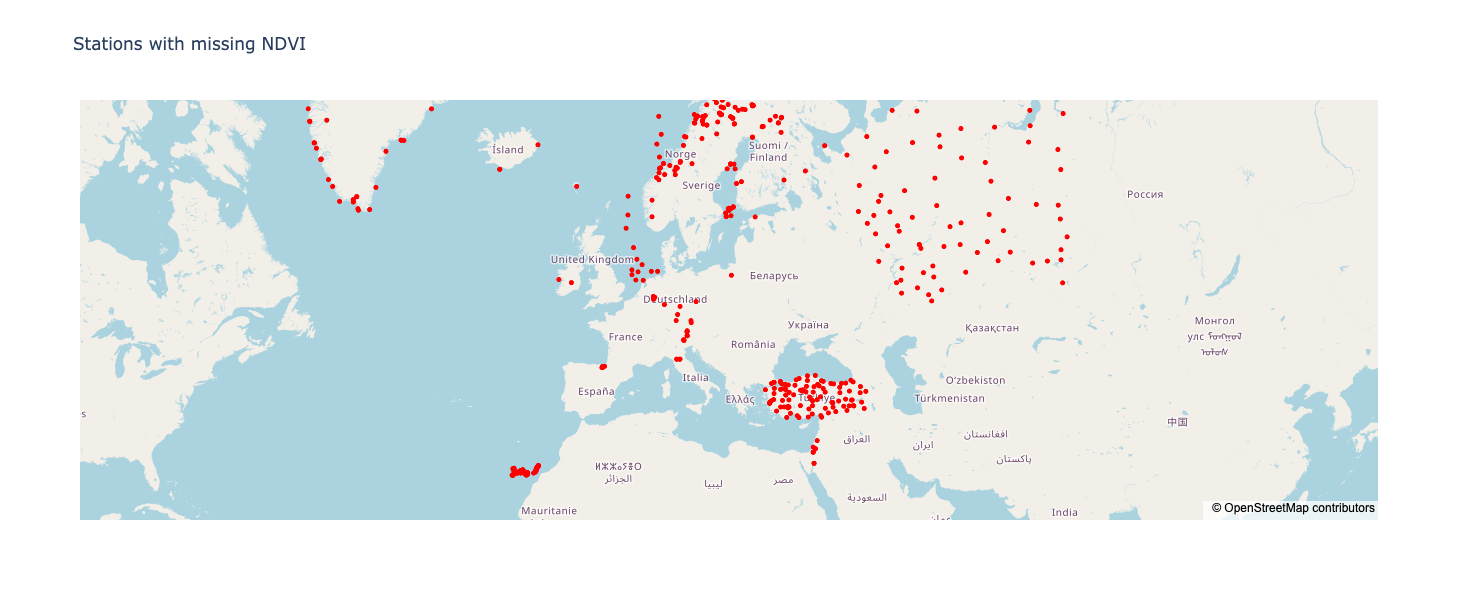

In [43]:
null_ndvi_staids = residuals_df[residuals_df["ndvi"].isna()]["STAID"].unique()                  
null_stations = stations_gdf[stations_gdf["STAID"].isin(null_ndvi_staids)]                      
                                                                                              
fig = px.scatter_map(                                                                           
  null_stations,                                                                              
  lat=null_stations.geometry.y,                                                               
  lon=null_stations.geometry.x,                                                               
  hover_data=["STAID", "CN"],                                                      
  zoom=2,                                                                                     
  center={"lat": 50, "lon": 20},                                                              
  map_style="open-street-map",                                                                
  title="Stations with missing NDVI",                                                         
)                                                                                               
fig.update_traces(marker=dict(size=6, color="red"))                                             
fig.update_layout(height=600, width=1000)                                                       
fig.show()